=== TRADE ANALYSIS ===
Total Trades: 77
Win Rate:     32.5%
Avg Win:      0.0539
Avg Loss:     -0.0139
Profit Factor:1.87

Avg Trade Duration: 15.3 days
Max Trade Duration: 58 days


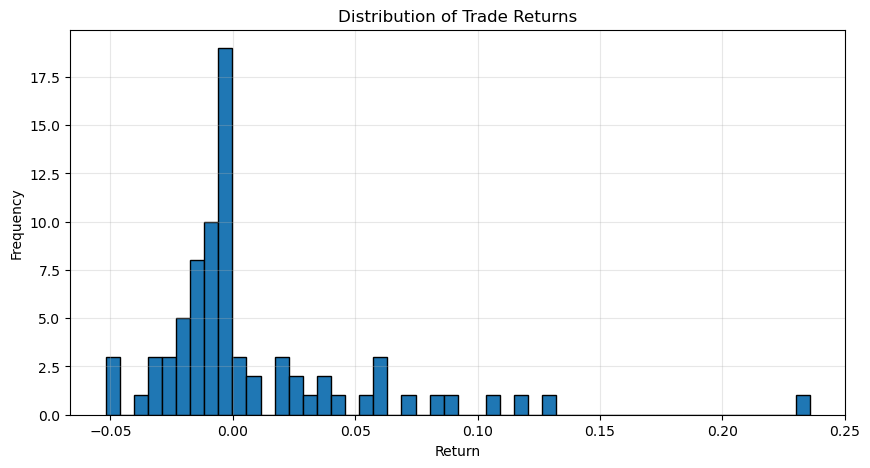


=== PERFORMANCE BY VOLATILITY REGIME ===
                   mean     std  count  annualized  sharpe
regime                                                    
High Volatility  0.0001  0.0138    763      0.0259  0.1182
Low Volatility   0.0000  0.0063    764      0.0055  0.0555

=== COVID CRASH PERFORMANCE ===
Strategy Return: 12.87%
NIFTY Return:    -13.88%


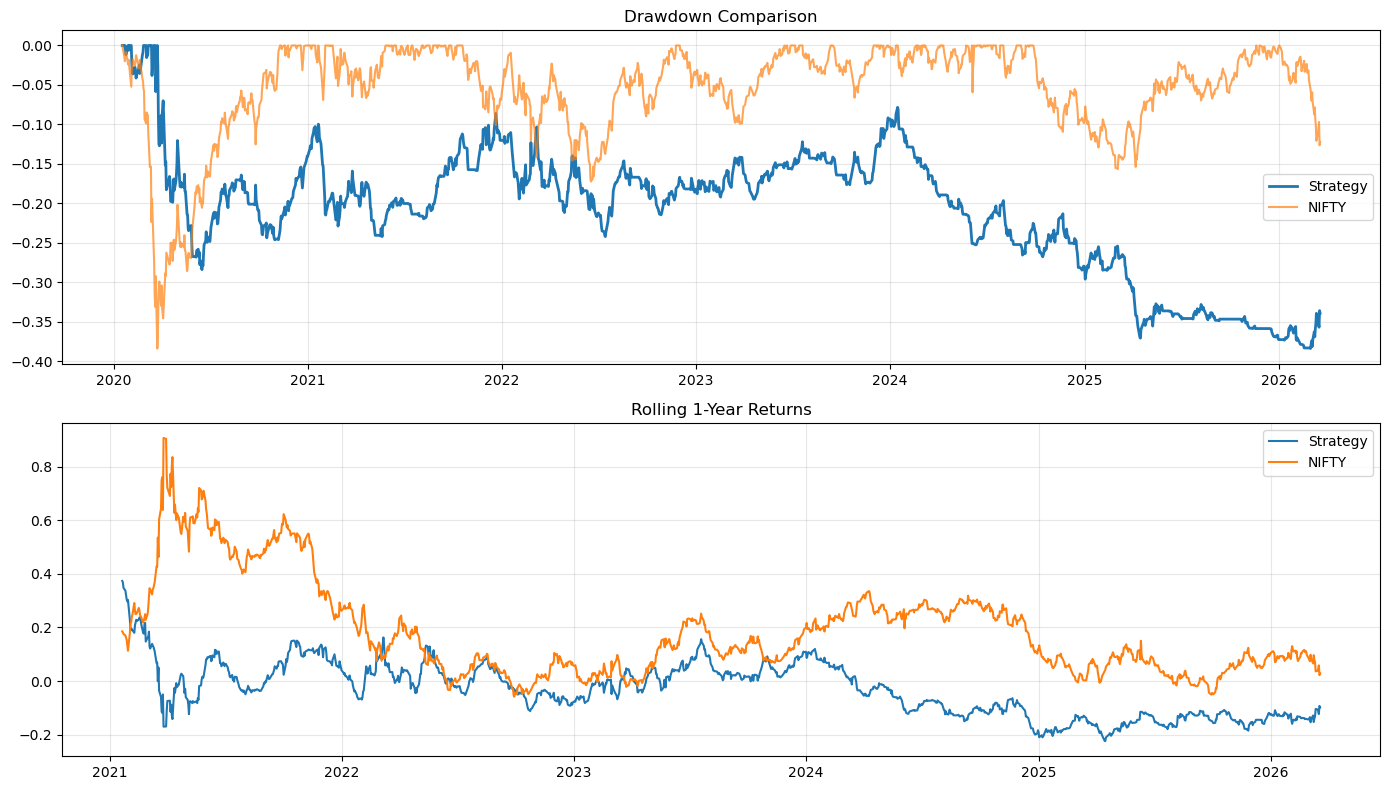

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =============================================
# 1. LOAD DATA
# =============================================
market = pd.read_csv("../backtesting/market_backtest_v7.csv")

market["Date"] = pd.to_datetime(market["Date"])
market = market.set_index("Date")

# =============================================
# 2. TRADE-LEVEL ANALYSIS (FIXED)
# =============================================

# Identify active position periods
in_position = market["position"] != 0

# Trade IDs (only when entering/exiting trades)
market["trade_id"] = (in_position != in_position.shift()).cumsum()
market["trade_id"] = market["trade_id"] * in_position

# Trade returns
trade_returns = market.groupby("trade_id")["strategy_ret_v2"].sum()
trade_returns = trade_returns[trade_returns.index != 0]  # remove idle group

# Trade statistics
win_rate = (trade_returns > 0).mean()
avg_win = trade_returns[trade_returns > 0].mean()
avg_loss = trade_returns[trade_returns < 0].mean()
num_trades = len(trade_returns)

# Robust Profit Factor
total_profit = trade_returns[trade_returns > 0].sum()
total_loss = trade_returns[trade_returns < 0].sum()
profit_factor = abs(total_profit / total_loss) if total_loss != 0 else np.inf

print("=== TRADE ANALYSIS ===")
print(f"Total Trades: {num_trades}")
print(f"Win Rate:     {win_rate:.1%}")
print(f"Avg Win:      {avg_win:.4f}")
print(f"Avg Loss:     {avg_loss:.4f}")
print(f"Profit Factor:{profit_factor:.2f}")

# Trade Duration
trade_duration = market.groupby("trade_id").size()
trade_duration = trade_duration[trade_duration.index != 0]

print(f"\nAvg Trade Duration: {trade_duration.mean():.1f} days")
print(f"Max Trade Duration: {trade_duration.max()} days")

# Trade Return Distribution
plt.figure(figsize=(10, 5))
plt.hist(trade_returns, bins=50, edgecolor='black')
plt.title("Distribution of Trade Returns")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()

# =============================================
# 3. REGIME ANALYSIS (SAFE)
# =============================================
vol_median = market["vol_signal"].median()

market["regime"] = np.where(
    market["vol_signal"] > vol_median,
    "High Volatility",
    "Low Volatility"
)

regime_perf = market.groupby("regime")["strategy_ret_v2"].agg(['mean', 'std', 'count'])

# Annualized return
regime_perf["annualized"] = regime_perf["mean"] * 252

# Safe Sharpe
regime_perf["sharpe"] = np.where(
    regime_perf["std"] != 0,
    regime_perf["mean"] / regime_perf["std"] * np.sqrt(252),
    0
)

print("\n=== PERFORMANCE BY VOLATILITY REGIME ===")
print(regime_perf.round(4))

# =============================================
# 4. STRESS TEST (COVID PERIOD)
# =============================================
covid_period = market.loc["2020-02-01":"2020-06-30"]

strategy_covid = (1 + covid_period["strategy_ret_v2"]).prod() - 1
benchmark_covid = (1 + covid_period["nifty_ret"]).prod() - 1

print("\n=== COVID CRASH PERFORMANCE ===")
print(f"Strategy Return: {strategy_covid:.2%}")
print(f"NIFTY Return:    {benchmark_covid:.2%}")

# =============================================
# 5. VISUALIZATION
# =============================================
plt.figure(figsize=(14, 8))

# Drawdown
plt.subplot(2, 1, 1)
plt.plot(market.index, market["strategy_dd"], label="Strategy", linewidth=2)
plt.plot(market.index, market["benchmark_dd"], label="NIFTY", alpha=0.7)
plt.title("Drawdown Comparison")
plt.legend()
plt.grid(True, alpha=0.3)

# Rolling Returns
plt.subplot(2, 1, 2)
plt.plot(market.index, market["rolling_return"], label="Strategy")
plt.plot(market.index, market["rolling_benchmark"], label="NIFTY")
plt.title("Rolling 1-Year Returns")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================
# 6. SAVE
# =============================================
market.to_csv("../backtesting/market_backtest_v8.csv")